In [1]:
#################################################
# 1. Python Imports
#################################################

# Install only if needed (run once)
#!pip install -r ../requirements.txt

import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import joblib

In [2]:
#################################################
# 2. Define Project Paths
#################################################

BASE_PATH = "../"  # notebook is inside src/

DATA_PATH = os.path.join(BASE_PATH, "data")
OUTPUT_PATH = os.path.join(BASE_PATH, "outputs")
MODEL_PATH = os.path.join(BASE_PATH, "models")

print(DATA_PATH, OUTPUT_PATH, MODEL_PATH)

../data ../outputs ../models


In [3]:
#################################################
# 3. Load Input Dataset
#################################################

df = pd.read_csv(os.path.join(DATA_PATH, "inp_air_quality_raw_v1.csv"))
df_original = df.copy()

df.head()

,Estación,Título,latitud,longitud,Fecha,Periodo,SO2,NO,NO2,CO,...,vv,TMP,HR,PRB,RS,LL,BEN,TOL,MXIL,PM25
0,1,Estación Avenida Constitución,43.529806,-5.673428,2013-12-31,1,4.0,2.0,15.0,0.29,...,1.13,14.1,54.0,1009.0,17.0,0.0,0.10,0.60,0.40,3.0
1,1,Estación Avenida Constitución,43.529806,-5.673428,2013-12-31,2,3.0,1.0,14.0,0.25,...,0.48,14.1,55.0,1008.0,17.0,0.0,0.10,0.90,0.60,6.0
2,1,Estación Avenida Constitución,43.529806,-5.673428,2013-12-31,3,5.0,1.0,16.0,0.26,...,0.10,13.4,58.0,1007.0,17.0,0.0,0.10,0.92,1.88,6.0
3,1,Estación Avenida Constitución,43.529806,-5.673428,2013-12-31,4,4.0,1.0,5.0,0.24,...,0.75,15.3,53.0,1006.0,17.0,0.0,0.13,1.23,3.20,1.0
4,1,Estación Avenida Constitución,43.529806,-5.673428,2013-12-31,5,4.0,2.0,13.0,0.26,...,0.78,14.9,55.0,1006.0,17.0,0.0,0.10,0.50,0.63,1.0


In [4]:
#################################################
# 4. Rename Columns & Format Data
#################################################

df = df.rename(columns={
    "Estación": "station",
    "Título": "station_name",
    "latitud": "latitude",
    "longitud": "longitude",
    "Fecha": "date",
    "Periodo": "hour",
    "dd": "wind_direction",
    "vv": "wind_speed",
    "TMP": "temperature",
    "HR": "humidity",
    "PRB": "pressure",
    "RS": "solar_radiation",
    "LL": "rain",
    "PM25": "PM25"
})

df["date"] = pd.to_datetime(df["date"], errors="coerce")

df.head()

,station,station_name,latitude,longitude,date,hour,SO2,NO,NO2,CO,...,wind_speed,temperature,humidity,pressure,solar_radiation,rain,BEN,TOL,MXIL,PM25
0,1,Estación Avenida Constitución,43.529806,-5.673428,2013-12-31,1,4.0,2.0,15.0,0.29,...,1.13,14.1,54.0,1009.0,17.0,0.0,0.10,0.60,0.40,3.0
1,1,Estación Avenida Constitución,43.529806,-5.673428,2013-12-31,2,3.0,1.0,14.0,0.25,...,0.48,14.1,55.0,1008.0,17.0,0.0,0.10,0.90,0.60,6.0
2,1,Estación Avenida Constitución,43.529806,-5.673428,2013-12-31,3,5.0,1.0,16.0,0.26,...,0.10,13.4,58.0,1007.0,17.0,0.0,0.10,0.92,1.88,6.0
3,1,Estación Avenida Constitución,43.529806,-5.673428,2013-12-31,4,4.0,1.0,5.0,0.24,...,0.75,15.3,53.0,1006.0,17.0,0.0,0.13,1.23,3.20,1.0
4,1,Estación Avenida Constitución,43.529806,-5.673428,2013-12-31,5,4.0,2.0,13.0,0.26,...,0.78,14.9,55.0,1006.0,17.0,0.0,0.10,0.50,0.63,1.0


In [5]:
#################################################
# 5. Create Target Variable
#################################################

def air_quality(pm25):
    if pm25 < 20:
        return "Good"
    elif pm25 < 50:
        return "Moderate"
    else:
        return "Poor"

df["Air_Quality_Class"] = df["PM25"].apply(air_quality)

df[["PM25", "Air_Quality_Class"]].head()

,PM25,Air_Quality_Class
0,3.0,Good
1,6.0,Good
2,6.0,Good
3,1.0,Good
4,1.0,Good


In [6]:
#################################################
# 6. Feature Selection & Cleaning
#################################################

# Feature PM25 is dropped to avoid data leakage

features = [
    "latitude","longitude","hour",
    "SO2","NO","NO2","CO","O3",
    "wind_direction","wind_speed",
    "temperature","humidity","pressure",
    "solar_radiation","rain"
]

df_ml = df[features + ["Air_Quality_Class"]].dropna()

print("Shape:", df_ml.shape)

Shape: (8613, 16)


In [7]:
#################################################
# 7. Save Processed Dataset
#################################################

df_ml.to_csv(
    os.path.join(DATA_PATH, "inp_air_quality_processed_v1.csv"),
    index=False
)

In [8]:
#################################################
# 8. Load Processed Dataset
#################################################

df = pd.read_csv(
    os.path.join(DATA_PATH, "inp_air_quality_processed_v1.csv")
)

df.head()

,latitude,longitude,hour,SO2,NO,NO2,CO,O3,wind_direction,wind_speed,temperature,humidity,pressure,solar_radiation,rain,Air_Quality_Class
0,43.529806,-5.673428,1,4.0,2.0,15.0,0.29,58.0,158.0,1.13,14.1,54.0,1009.0,17.0,0.0,Good
1,43.529806,-5.673428,2,3.0,1.0,14.0,0.25,54.0,203.0,0.48,14.1,55.0,1008.0,17.0,0.0,Good
2,43.529806,-5.673428,3,5.0,1.0,16.0,0.26,50.0,5.0,0.10,13.4,58.0,1007.0,17.0,0.0,Good
3,43.529806,-5.673428,4,4.0,1.0,5.0,0.24,68.0,181.0,0.75,15.3,53.0,1006.0,17.0,0.0,Good
4,43.529806,-5.673428,5,4.0,2.0,13.0,0.26,56.0,181.0,0.78,14.9,55.0,1006.0,17.0,0.0,Good


In [9]:
#################################################
# 9. Define Features and Target
#################################################

X = df.drop("Air_Quality_Class", axis=1)
y = df["Air_Quality_Class"]

In [10]:
#################################################
# 10. Train / Validation / Test Split
#################################################

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))

Train: 6029
Val: 1292
Test: 1292


In [11]:
#################################################
# 11. Feature Scaling
#################################################

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [12]:
#################################################
# 12. Train Models
#################################################

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model1 = LogisticRegression(max_iter=10000)
model2 = DecisionTreeClassifier()
model3 = RandomForestClassifier()

model1.fit(X_train, y_train)
model2.fit(X_train, y_train)
model3.fit(X_train, y_train)

RandomForestClassifier()

In [13]:
#################################################
# 13. Model Evaluation
#################################################

from sklearn.metrics import accuracy_score

pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

acc1 = accuracy_score(y_test, pred1)
acc2 = accuracy_score(y_test, pred2)
acc3 = accuracy_score(y_test, pred3)

print("Logistic Regression:", acc1)
print("Decision Tree:", acc2)
print("Random Forest:", acc3)

Logistic Regression: 0.8560371517027864
Decision Tree: 0.8258513931888545
Random Forest: 0.8823529411764706


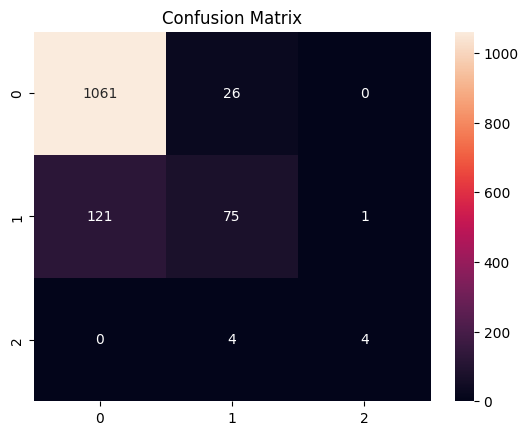

In [14]:
#################################################
# 14. Confusion Matrix (Random Forest)
#################################################

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred3)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")

plt.savefig(
    os.path.join(OUTPUT_PATH, "outp_confusion_matrix_v1.png")
)

plt.show()

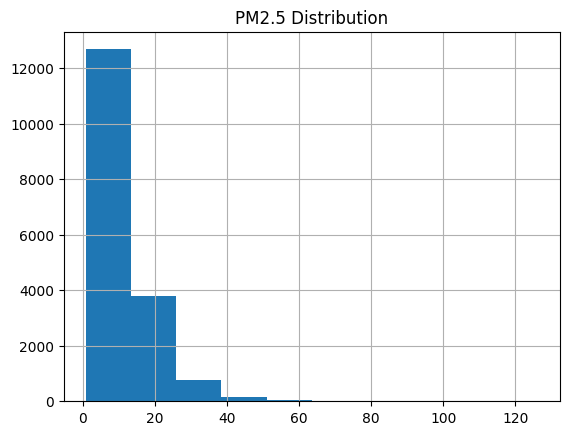

In [15]:
#################################################
# 15. PM2.5 Distribution Plot
#################################################

df_original["PM25"].hist()

plt.title("PM2.5 Distribution")

plt.savefig(
    os.path.join(OUTPUT_PATH, "outp_pm25_histogram_v1.png")
)

plt.show()

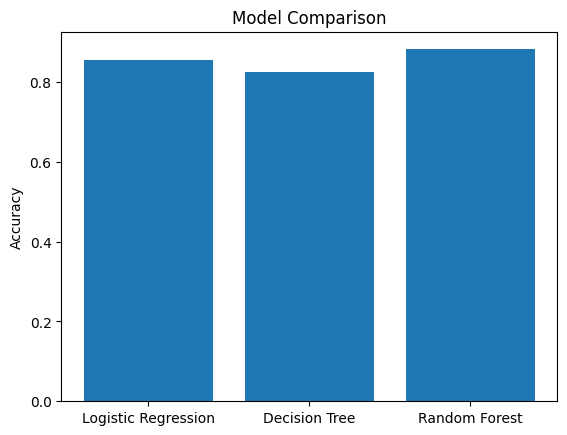

In [16]:
#################################################
# 16. Model Comparison Plot
#################################################

models = ["Logistic Regression","Decision Tree","Random Forest"]
scores = [acc1, acc2, acc3]

plt.bar(models, scores)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.savefig(
    os.path.join(OUTPUT_PATH, "outp_model_comparison_v1.png")
)

plt.show()

In [17]:
#################################################
# 17. Save Best Model
#################################################

model_file = os.path.join(
    MODEL_PATH, "model_randomforest_v1.pkl"
)

joblib.dump(model3, model_file)

print("Model saved at:", model_file)

Model saved at: ../models/model_randomforest_v1.pkl
